<a href="https://colab.research.google.com/github/gergielias-max/Deep-learning/blob/main/Deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [6]:
df = pd.read_csv('/Measurement_summary.csv')
df.head()

print(df.columns)
print(df.head())
print(df.columns)

Index(['Measurement date', 'Station code', 'Address', 'Latitude', 'Longitude',
       'SO2', 'NO2', 'O3', 'CO', 'PM10', 'PM2.5'],
      dtype='object')
   Measurement date  Station code  \
0  2017-01-01 00:00           101   
1  2017-01-01 01:00           101   
2  2017-01-01 02:00           101   
3  2017-01-01 03:00           101   
4  2017-01-01 04:00           101   

                                             Address   Latitude   Longitude  \
0  19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...  37.572016  127.005008   
1  19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...  37.572016  127.005008   
2  19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...  37.572016  127.005008   
3  19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...  37.572016  127.005008   
4  19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...  37.572016  127.005008   

     SO2    NO2     O3   CO  PM10  PM2.5  
0  0.004  0.059  0.002  1.2  73.0   57.0  
1  0.004  0.058  0.002  1.2  71.0   59.0  
2  0.004  0.056  0.00

In [7]:
# ta bort NaN
df = df.dropna()

# välj relevanta features
# Exempel – anpassa beroende på dataset!
features = ['PM10', 'NO2', 'CO', 'SO2']
target = 'PM2.5'

X = df[features]
y = df[target]

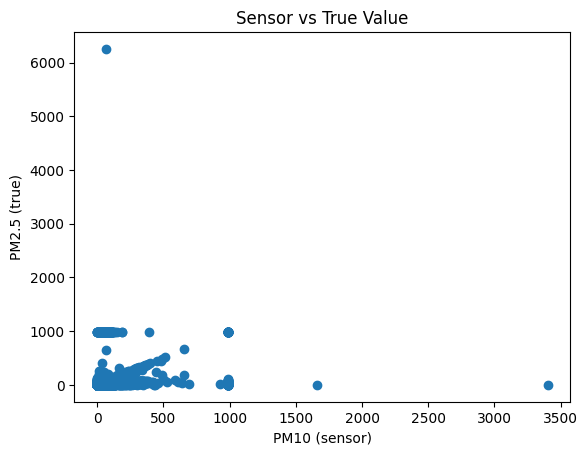

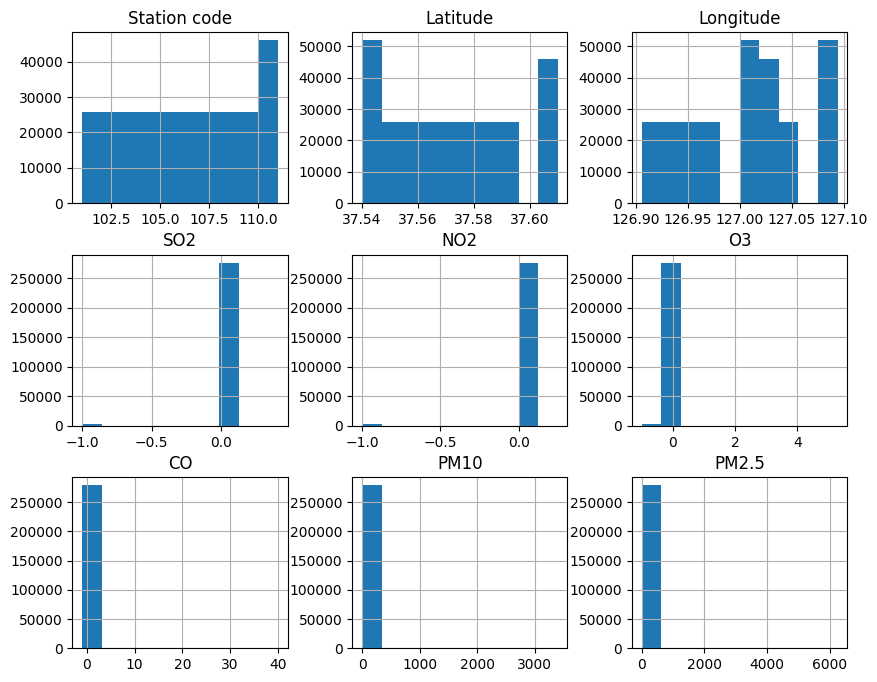

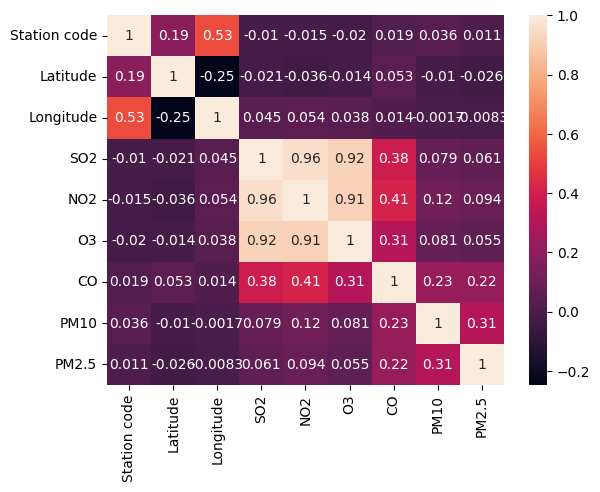

In [8]:
# scatter (viktig!)
plt.scatter(X['PM10'], y)
plt.xlabel('PM10 (sensor)')
plt.ylabel('PM2.5 (true)')
plt.title('Sensor vs True Value')
plt.show()

# histogram (bara numeriska)
numeric_df = df.select_dtypes(include=['number'])
numeric_df.hist(figsize=(10,8))
plt.show()

# correlation
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [11]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [12]:
def evaluate(y_true, y_pred, name):
    print(f"--- {name} ---")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))
    print()

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

--- Linear Regression ---
MAE: 10.162291688671576
RMSE: 34.58890789110936
R2: 0.13397921223270592

--- Random Forest ---
MAE: 8.380131072179212
RMSE: 37.550852218702396
R2: -0.020690829351217133



In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
rf2 = RandomForestRegressor(n_estimators=200, max_depth=10)
rf2.fit(X_train, y_train)

y_pred_rf2 = rf2.predict(X_test)

evaluate(y_test, y_pred_rf2, "Improved Random Forest")

--- Improved Random Forest ---
MAE: 7.053673228275905
RMSE: 33.217633613721446
R2: 0.20128470997126036



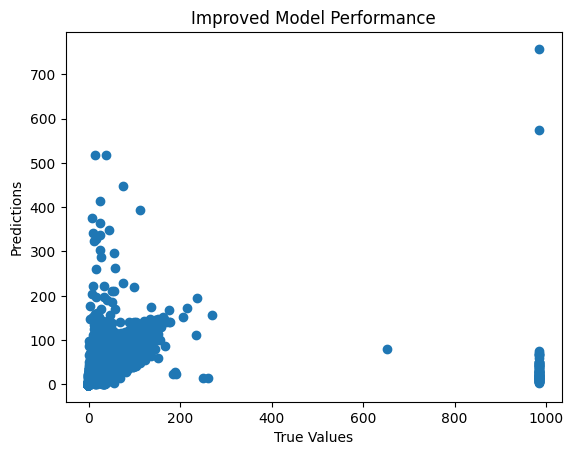

In [15]:
plt.scatter(y_test, y_pred_rf2)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("Improved Model Performance")
plt.show()

In [16]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Improved RF'],
    'R2': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_rf2)
    ]
})

print(results)

               Model        R2
0  Linear Regression  0.133979
1      Random Forest -0.020691
2        Improved RF  0.201285
